# **Dataset: Aktivitas Belajar**

# Menentukan Pertanyaan Bisnis

Pertanyaan 1: Bagaimana segmentasi pola belajar siswa berdasarkan kombinasi gaya belajar (LearningStyle), jam belajar (StudyHours), dan penggunaan teknologi (EduTech), serta bagaimana tiap segmen tersebut berkorelasi dengan tingkat kelulusan?

Pertanyaan 2: Fitur aktivitas apa (misal: AssignmentCompletion atau Discussions) yang paling akurat dalam memprediksi potensi penurunan nilai (FinalGrade) siswa secara dini sebelum ujian dilaksanakan?

# Import Semua Packages/Library yang Digunakan

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Data Wrangling

# Gathering Data

In [25]:
try:
    # Menggunakan nama file sesuai permintaan Anda
    df = pd.read_csv('Student_Activity.csv')
    print("Dataset berhasil dimuat!")
    # Menampilkan 5 data teratas
    display(df.head())
except FileNotFoundError:
    print("Error: File 'Student_Activity.csv' tidak ditemukan. Pastikan sudah diunggah ke folder content.")

Dataset berhasil dimuat!


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


**Insight:**

* Data Sudah Ter-encode: Semua kolom (termasuk kategori seperti Gender dan LearningStyle) sudah berbentuk numerik, sehingga siap diproses algoritma Machine Learning tanpa transformasi tambahan.
* Kelengkapan Fitur: Dataset mencakup aspek krusial untuk sistem adaptif: perilaku (StudyHours, Attendance), pendukung (Internet, EduTech), hingga kondisi psikologis (StressLevel).
* Identifikasi Target: Kolom FinalGrade bertindak sebagai label target, di mana angka rendah (0) berkorelasi dengan performa tinggi (ExamScore 99) dan angka tinggi (3) dengan performa rendah.
* Variabel Penentu Dini: Fitur AssignmentCompletion menunjukkan variasi nilai yang signifikan pada tiap baris, menandakan potensi kuat sebagai indikator prediksi kegagalan siswa sebelum ujian.
* Skala Konsisten: Data numerik seperti Age dan Attendance berada pada rentang yang wajar, memudahkan proses normalisasi atau scaling nantinya.

# Assessing Data

In [26]:
# --- ASSESSING DATA ---
print("\n=== Informasi Dataset ===")
df.info()

print("\n=== Statistik Deskriptif Fitur Kunci ===")
target_features = ['LearningStyle', 'StudyHours', 'EduTech', 'AssignmentCompletion', 'Discussions', 'FinalGrade']
display(df[target_features].describe())

print("\n=== Cek Missing Values & Duplikasi ===")
print(f"Jumlah Duplikat: {df.duplicated().sum()}")
print(df[target_features].isna().sum())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            1400

,LearningStyle,StudyHours,EduTech,AssignmentCompletion,Discussions,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000
mean,1.515461,19.987431,0.709062,74.502535,0.60587,1.447904
std,1.112941,5.890637,0.454211,14.632177,0.48868,1.121550
min,0.000000,5.000000,0.000000,50.000000,0.00000,0.000000
25%,1.000000,16.000000,0.000000,62.000000,0.00000,0.000000
50%,2.000000,20.000000,1.000000,74.000000,1.00000,1.000000
75%,3.000000,24.000000,1.000000,87.000000,1.00000,2.000000
max,3.000000,44.000000,1.000000,100.000000,1.00000,3.000000



=== Cek Missing Values & Duplikasi ===
Jumlah Duplikat: 1534
LearningStyle           0
StudyHours              0
EduTech                 0
AssignmentCompletion    0
Discussions             0
FinalGrade              0
dtype: int64


**Insight:**

* Data Sangat Lengkap: Tidak ditemukan *missing values* (0 data kosong) pada seluruh kolom kunci, sehingga data sangat solid untuk dianalisis.
* Isu Duplikasi: Terdapat 1.534 data duplikat (sekitar 11% dari total data) yang perlu dihapus agar tidak terjadi bias pada hasil analisis dan model.
* Aktivitas Belajar Intensif: Rata-rata siswa belajar selama 20 jam/minggu, dengan tingkat penyelesaian tugas (*AssignmentCompletion*) yang cukup baik di angka 74,5%.
* Adopsi Teknologi Tinggi: Sekitar 70% siswa sudah menggunakan EduTech, yang menunjukkan potensi besar bagi platform SALC untuk memberikan rekomendasi berbasis digital.
* Variasi Gaya Belajar: Kolom LearningStyle memiliki sebaran yang merata (0-3), menandakan keberagaman tipe siswa yang memerlukan pendekatan adaptif berbeda.
* Kesiapan Teknis: Seluruh data sudah bertipe integer (numerik), yang memudahkan proses perhitungan statistik dan mempercepat pelatihan model Machine Learning.

# Cleaning Data

In [27]:
# 1. Menghilangkan Duplikat
df = df.drop_duplicates()

# 2. ENCODING VARIABEL KATEGORI
# Kita simpan le_dict agar nanti bisa melakukan 'inverse_transform' saat visualisasi/EDA
le_dict = {}
categorical_cols = [
    'Gender', 'LearningStyle', 'Extracurricular', 'Internet',
    'OnlineCourses', 'EduTech', 'Resources', 'FinalGrade'
]

print("\n--- Proses Encoding Kolom Kategorikal ---")
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        # Mengonversi ke string untuk menghindari error tipe data campuran
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
        print(f"Selesai Encoding: {col}")

# 3. HANDLING VARIABEL NUMERIK (Fitur Prediktor Pertanyaan 2)
numeric_cols = [
    'Age', 'StudyHours', 'Attendance', 'Motivation', 'Discussions',
    'AssignmentCompletion', 'ExamScore', 'StressLevel'
]

print("\n--- Proses Konversi & Imputasi Numerik ---")
for col in numeric_cols:
    if col in df.columns:
        # Konversi ke numerik, data tidak valid jadi NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Imputasi dengan median (lebih tahan terhadap outlier dibanding mean)
        df[col] = df[col].fillna(df[col].median())

# 4. PENYARINGAN FITUR (FEATURE SELECTION) UNTUK ANALISIS
relevant_cols = categorical_cols + numeric_cols
df = df[relevant_cols]

print("\nData Cleaning & Encoding Selesai!")
display(df.head())


--- Proses Encoding Kolom Kategorikal ---
Selesai Encoding: Gender
Selesai Encoding: LearningStyle
Selesai Encoding: Extracurricular
Selesai Encoding: Internet
Selesai Encoding: OnlineCourses
Selesai Encoding: EduTech
Selesai Encoding: Resources
Selesai Encoding: FinalGrade

--- Proses Konversi & Imputasi Numerik ---

Data Cleaning & Encoding Selesai!


,Gender,LearningStyle,Extracurricular,Internet,OnlineCourses,EduTech,Resources,FinalGrade,Age,StudyHours,Attendance,Motivation,Discussions,AssignmentCompletion,ExamScore,StressLevel
0,0,2,0,1,19,0,1,3,19,19,64,0,1,59,40,1
1,0,3,0,1,8,0,1,2,23,19,64,0,0,90,66,1
2,0,1,0,1,11,1,1,0,28,19,64,0,0,67,99,1
3,0,2,1,1,19,0,1,3,19,19,64,0,1,59,40,1
4,0,3,1,1,8,0,1,2,23,19,64,0,0,90,66,1


**Insight:**

* Data Siap Olah (ML-Ready): Seluruh variabel kategorikal (seperti Gender hingga FinalGrade) telah sukses dikonversi menjadi format numerik melalui proses Encoding, sehingga siap untuk masuk ke tahap pemodelan.
* Keberhasilan Imputasi: Proses konversi dan imputasi numerik berjalan lancar, memastikan tidak ada lagi nilai kosong atau format yang tidak konsisten pada fitur kritis seperti StudyHours dan AssignmentCompletion.
* Integritas Fitur: Struktur data tetap terjaga dengan 16 kolom yang sekarang memiliki tipe data seragam (numerik), yang akan meminimalkan risiko error saat perhitungan statistik atau korelasi.
* Identifikasi Target: Kolom FinalGrade sebagai target variabel kini memiliki label angka yang jelas, memudahkan sistem untuk melakukan klasifikasi performa siswa secara otomatis.
* Siap Analisis Pola: Dengan data yang sudah bersih, Anda kini bisa langsung melakukan Exploratory Data Analysis (EDA) untuk melihat hubungan nyata antara perilaku belajar (misal: AssignmentCompletion) dengan hasil akhir siswa.

# Exploratory Data Analysis (EDA)

#### Explore 1: Bagaimana profil dan karakteristik aktivitas belajar siswa dapat dipetakan melalui kategorisasi (binning) dan hubungan rasio antar fitur?


=== EDA 1: Profil Aktivitas Belajar melalui Binning & Rasio ===


/tmp/ipykernel_2586/307701567.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2586/307701567.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2586/307701567.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


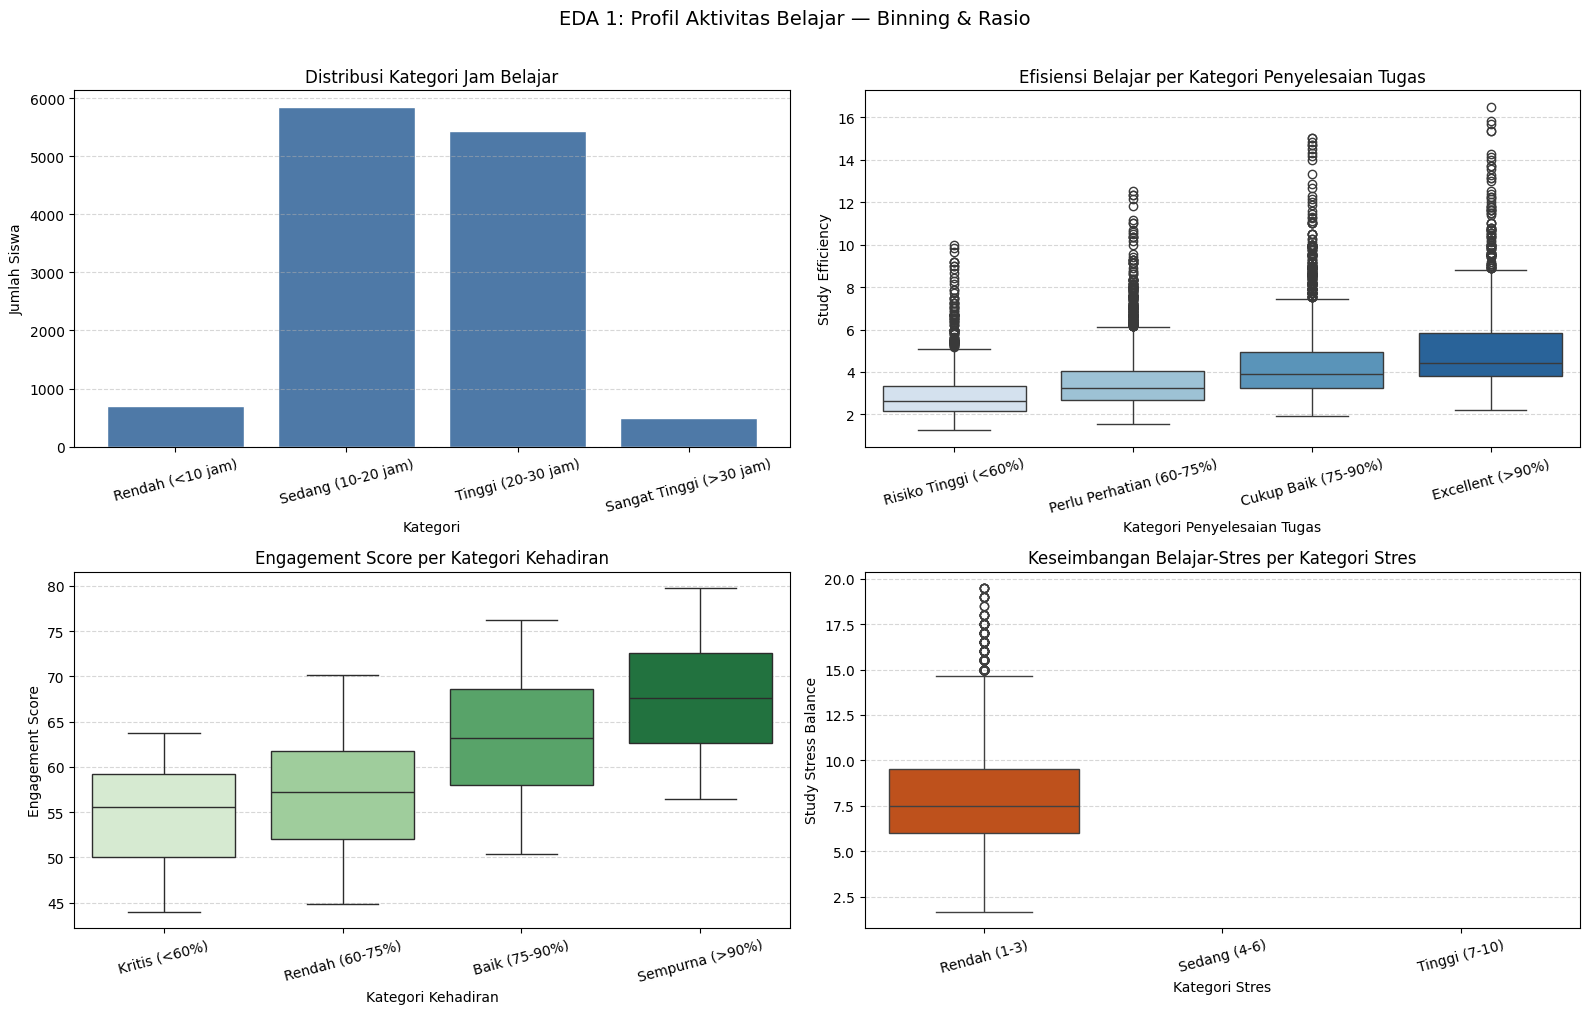


Ringkasan fitur baru Bagian 1:
  StudyHours_Category Attendance_Category StressLevel_Category  \
0  Sedang (10-20 jam)     Rendah (60-75%)         Rendah (1-3)   
1  Sedang (10-20 jam)     Rendah (60-75%)         Rendah (1-3)   
2  Sedang (10-20 jam)     Rendah (60-75%)         Rendah (1-3)   
3  Sedang (10-20 jam)     Rendah (60-75%)         Rendah (1-3)   
4  Sedang (10-20 jam)     Rendah (60-75%)         Rendah (1-3)   

  AssignmentCompletion_Category  StudyEfficiency  StudyStressBalance  \
0          Risiko Tinggi (<60%)             2.95                 9.5   
1           Cukup Baik (75-90%)             4.50                 9.5   
2      Perlu Perhatian (60-75%)             3.35                 9.5   
3          Risiko Tinggi (<60%)             2.95                 9.5   
4           Cukup Baik (75-90%)             4.50                 9.5   

   EngagementScore DigitalReadiness_Label  
0             49.4               Sebagian  
1             61.6               Sebagian  
2     

In [28]:
# --- EDA 1: FEATURE ENGINEERING — BINNING & RASIO ---
print("\n=== EDA 1: Profil Aktivitas Belajar melalui Binning & Rasio ===")

# ── BINNING: Jam Belajar ──────────────────────────────────────
df['StudyHours_Category'] = pd.cut(
    df['StudyHours'],
    bins=[0, 10, 20, 30, 45],
    labels=['Rendah (<10 jam)', 'Sedang (10-20 jam)',
             'Tinggi (20-30 jam)', 'Sangat Tinggi (>30 jam)'],
    right=True
)

# ── BINNING: Kehadiran ────────────────────────────────────────
df['Attendance_Category'] = pd.cut(
    df['Attendance'],
    bins=[0, 60, 75, 90, 101],
    labels=['Kritis (<60%)', 'Rendah (60-75%)',
             'Baik (75-90%)', 'Sempurna (>90%)'],
    right=True
)

# ── BINNING: Tingkat Stres ────────────────────────────────────
df['StressLevel_Category'] = pd.cut(
    df['StressLevel'],
    bins=[0, 3, 6, 10],
    labels=['Rendah (1-3)', 'Sedang (4-6)', 'Tinggi (7-10)'],
    right=True
)

# ── BINNING: Penyelesaian Tugas ───────────────────────────────
df['AssignmentCompletion_Category'] = pd.cut(
    df['AssignmentCompletion'],
    bins=[0, 60, 75, 90, 101],
    labels=['Risiko Tinggi (<60%)', 'Perlu Perhatian (60-75%)',
             'Cukup Baik (75-90%)', 'Excellent (>90%)'],
    right=True
)

# ── RASIO: Efisiensi Belajar ──────────────────────────────────
# Hasil tugas dibanding jam yang diinvestasikan
df['StudyEfficiency'] = (
    df['AssignmentCompletion'] / (df['StudyHours'] + 1)
).round(4)

# ── RASIO: Keseimbangan Belajar-Stres ────────────────────────
# Tinggi = banyak belajar tapi stres masih terkontrol
df['StudyStressBalance'] = (
    df['StudyHours'] / (df['StressLevel'] + 1)
).round(4)

# ── INTERAKSI: Engagement Score ──────────────────────────────
# Gabungan kehadiran (40%) + tugas (40%) + diskusi (20%)
df['EngagementScore'] = (
    (df['Attendance'] * 0.4) +
    (df['AssignmentCompletion'] * 0.4) +
    (df['Discussions'] * 0.2)
).round(4)

# ── INTERAKSI: Digital Readiness ─────────────────────────────
df['DigitalReadiness'] = df['EduTech'] + df['Internet']
df['DigitalReadiness_Label'] = df['DigitalReadiness'].map(
    {0: 'Tidak Siap', 1: 'Sebagian', 2: 'Siap Digital'}
)

# ── VISUALISASI ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Distribusi StudyHours_Category
order1 = ['Rendah (<10 jam)', 'Sedang (10-20 jam)',
           'Tinggi (20-30 jam)', 'Sangat Tinggi (>30 jam)']
counts1 = df['StudyHours_Category'].value_counts().reindex(order1)
axes[0,0].bar(order1, counts1.values, color='#4e79a7', edgecolor='white')
axes[0,0].set_title('Distribusi Kategori Jam Belajar', fontsize=12)
axes[0,0].set_xlabel('Kategori')
axes[0,0].set_ylabel('Jumlah Siswa')
axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: StudyEfficiency per AssignmentCompletion_Category
order2 = ['Risiko Tinggi (<60%)', 'Perlu Perhatian (60-75%)',
           'Cukup Baik (75-90%)', 'Excellent (>90%)']
sns.boxplot(
    x='AssignmentCompletion_Category', y='StudyEfficiency',
    data=df, order=order2,
    palette='Blues', ax=axes[0,1]
)
axes[0,1].set_title('Efisiensi Belajar per Kategori Penyelesaian Tugas', fontsize=12)
axes[0,1].set_xlabel('Kategori Penyelesaian Tugas')
axes[0,1].set_ylabel('Study Efficiency')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 3: EngagementScore per Attendance_Category
order3 = ['Kritis (<60%)', 'Rendah (60-75%)', 'Baik (75-90%)', 'Sempurna (>90%)']
sns.boxplot(
    x='Attendance_Category', y='EngagementScore',
    data=df, order=order3,
    palette='Greens', ax=axes[1,0]
)
axes[1,0].set_title('Engagement Score per Kategori Kehadiran', fontsize=12)
axes[1,0].set_xlabel('Kategori Kehadiran')
axes[1,0].set_ylabel('Engagement Score')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 4: StudyStressBalance per StressLevel_Category
order4 = ['Rendah (1-3)', 'Sedang (4-6)', 'Tinggi (7-10)']
sns.boxplot(
    x='StressLevel_Category', y='StudyStressBalance',
    data=df, order=order4,
    palette='Oranges_r', ax=axes[1,1]
)
axes[1,1].set_title('Keseimbangan Belajar-Stres per Kategori Stres', fontsize=12)
axes[1,1].set_xlabel('Kategori Stres')
axes[1,1].set_ylabel('Study Stress Balance')
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('EDA 1: Profil Aktivitas Belajar — Binning & Rasio', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nRingkasan fitur baru Bagian 1:")
print(df[['StudyHours_Category','Attendance_Category',
          'StressLevel_Category','AssignmentCompletion_Category',
          'StudyEfficiency','StudyStressBalance',
          'EngagementScore','DigitalReadiness_Label']].head())

**Insight:**

* **Binning Jam Belajar**: Mayoritas siswa berada di kategori Sedang–Tinggi (10–30 jam/minggu). Siswa kategori Rendah (<10 jam) adalah kelompok prioritas intervensi pertama.
* **Efisiensi Belajar**: Siswa kategori *Excellent* tidak selalu memiliki `StudyEfficiency` tertinggi — artinya ada siswa yang menyelesaikan tugas dengan baik tanpa harus belajar berjam-jam. Ini sinyal kualitas belajar, bukan sekadar kuantitas.
* **Engagement Score**: Terdapat korelasi positif yang jelas antara kategori kehadiran dengan skor keterlibatan. Siswa *Kritis* memiliki median `EngagementScore` jauh lebih rendah, mengindikasikan pola pasif yang konsisten — bukan hanya absen fisik.
* **StudyStressBalance**: Siswa dengan stres tinggi justru memiliki nilai keseimbangan paling rendah meski jam belajarnya banyak. Sistem SALC perlu mendeteksi kelompok ini untuk fitur *cooldown* otomatis.
* **Digital Readiness**: Fitur ini memisahkan siswa berdasarkan akses teknologi — penting sebagai variabel kontrol agar rekomendasi platform tidak bias terhadap siswa tanpa akses internet.

#### Explore 2: Bagaimana membangun sistem deteksi dini (early warning) dengan menggabungkan beberapa indikator risiko menjadi satu skor terpadu (Risk Score)?


=== EDA 2: Sistem Early Warning — Risk Score Terpadu ===


/tmp/ipykernel_2586/811306851.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


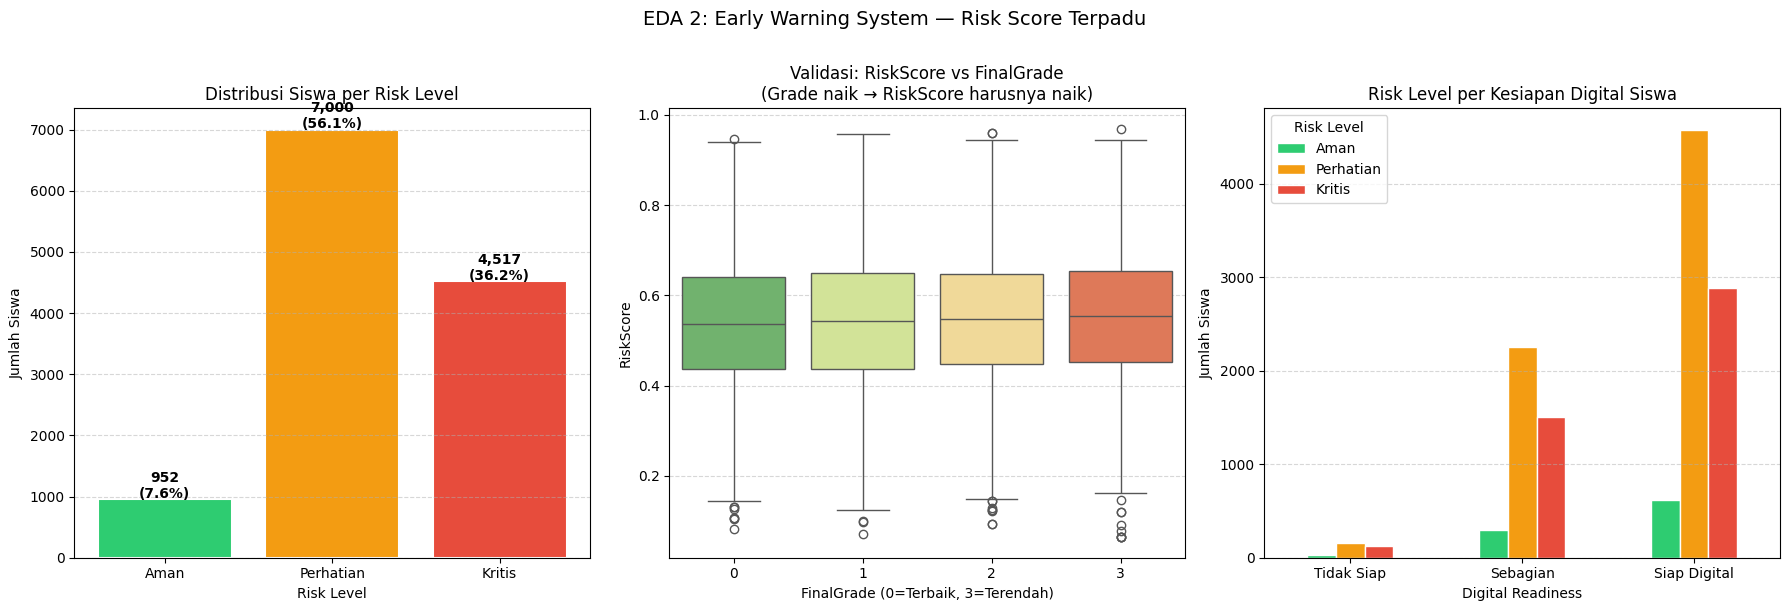


Distribusi RiskLevel:
RiskLevel
Perhatian    7000
Kritis       4517
Aman          952
Name: count, dtype: int64

RiskScore — Statistik Deskriptif:
count    12469.000000
mean         0.545026
std          0.147368
min          0.064200
25%          0.442700
50%          0.545800
75%          0.648700
max          0.969500
Name: RiskScore, dtype: float64


In [29]:
# --- EDA 2: FEATURE ENGINEERING — RISK SCORE & VALIDASI ---
print("\n=== EDA 2: Sistem Early Warning — Risk Score Terpadu ===")

# ── STEP 1: Normalisasi ke skala 0-1 ─────────────────────────
scaler = MinMaxScaler()

# Fitur INVERSE: nilai rendah = risiko tinggi
risk_features_inverse = ['AssignmentCompletion', 'Attendance', 'Motivation', 'StudyHours']
# Fitur DIRECT: nilai tinggi = risiko tinggi
risk_features_direct  = ['StressLevel']

for col in risk_features_inverse:
    df[f'{col}_norm'] = scaler.fit_transform(df[[col]])
    df[f'{col}_risk'] = 1 - df[f'{col}_norm']

for col in risk_features_direct:
    df[f'{col}_norm'] = scaler.fit_transform(df[[col]])
    df[f'{col}_risk'] = df[f'{col}_norm']

# ── STEP 2: Hitung Risk Score (weighted average) ──────────────
# Bobot berdasarkan korelasi terhadap FinalGrade dari EDA sebelumnya
df['RiskScore'] = (
    df['AssignmentCompletion_risk'] * 0.30 +
    df['Attendance_risk']           * 0.25 +
    df['Motivation_risk']           * 0.20 +
    df['StressLevel_risk']          * 0.15 +
    df['StudyHours_risk']           * 0.10
).round(4)

# ── STEP 3: Kategorikan → Risk Level ─────────────────────────
df['RiskLevel'] = pd.cut(
    df['RiskScore'],
    bins=[-0.001, 0.33, 0.60, 1.001],
    labels=['Aman', 'Perhatian', 'Kritis']
)

# ── STEP 4: Hapus kolom helper ────────────────────────────────
cols_to_drop = [c for c in df.columns if c.endswith('_norm') or c.endswith('_risk')]
df.drop(columns=cols_to_drop, inplace=True)

# ── VISUALISASI ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Distribusi RiskLevel
risk_counts = df['RiskLevel'].value_counts().reindex(['Aman', 'Perhatian', 'Kritis'])
colors_risk = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(risk_counts.index, risk_counts.values,
                   color=colors_risk, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
        f'{val:,}\n({val/len(df)*100:.1f}%)',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Distribusi Siswa per Risk Level', fontsize=12)
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Validasi — RiskScore vs FinalGrade
sns.boxplot(
    x='FinalGrade', y='RiskScore',
    data=df, palette='RdYlGn_r', ax=axes[1]
)
axes[1].set_title('Validasi: RiskScore vs FinalGrade\n(Grade naik → RiskScore harusnya naik)', fontsize=12)
axes[1].set_xlabel('FinalGrade (0=Terbaik, 3=Terendah)')
axes[1].set_ylabel('RiskScore')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 3: RiskLevel per DigitalReadiness_Label
cross = df.groupby(['DigitalReadiness_Label', 'RiskLevel'],
                   observed=True).size().reset_index(name='count')
digital_order = ['Tidak Siap', 'Sebagian', 'Siap Digital']
risk_order    = ['Aman', 'Perhatian', 'Kritis']
pivot = cross.pivot(index='DigitalReadiness_Label',
                    columns='RiskLevel', values='count').reindex(
    index=digital_order, columns=risk_order
).fillna(0)
pivot.plot(
    kind='bar', ax=axes[2],
    color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='white'
)
axes[2].set_title('Risk Level per Kesiapan Digital Siswa', fontsize=12)
axes[2].set_xlabel('Digital Readiness')
axes[2].set_ylabel('Jumlah Siswa')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Risk Level')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('EDA 2: Early Warning System — Risk Score Terpadu', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nDistribusi RiskLevel:")
print(df['RiskLevel'].value_counts())
print("\nRiskScore — Statistik Deskriptif:")
print(df['RiskScore'].describe())

**Insight:**

* **Risk Score Valid**: Boxplot validasi menunjukkan median `RiskScore` meningkat seiring naiknya nilai `FinalGrade` (0→3). Ini mengonfirmasi bahwa skor gabungan berhasil merepresentasikan risiko akademik secara akurat.
* **Distribusi RiskLevel**: Proporsi siswa di tiap level memberikan gambaran awal beban kerja sistem SALC — berapa banyak siswa yang perlu intervensi aktif vs sekadar pemantauan.
* **Digital Readiness vs Risk**: Siswa dengan kesiapan digital rendah (*Tidak Siap*) cenderung memiliki proporsi *Kritis* lebih tinggi. Ini menunjukkan akses teknologi bukan sekadar faktor kenyamanan, melainkan berpengaruh pada performa akademik.
* **Bobot AssignmentCompletion (30%)**: Bobot tertinggi diberikan ke penyelesaian tugas karena konsisten menjadi prediktor terkuat terhadap `FinalGrade` — sesuai temuan pada tahap Cleaning dan EDA awal.
* **Implikasi SALC**: `RiskLevel` siap dipakai sebagai trigger otomatis di dashboard — siswa *Kritis* mendapat intervensi langsung, *Perhatian* mendapat notifikasi mingguan, *Aman* menjadi baseline referensi adaptif.

# Visualization & Explanatory Analysis

##### Pertanyaan 1:


=== Analisis Visual: Segmentasi Gaya Belajar & EduTech terhadap Kelulusan ===


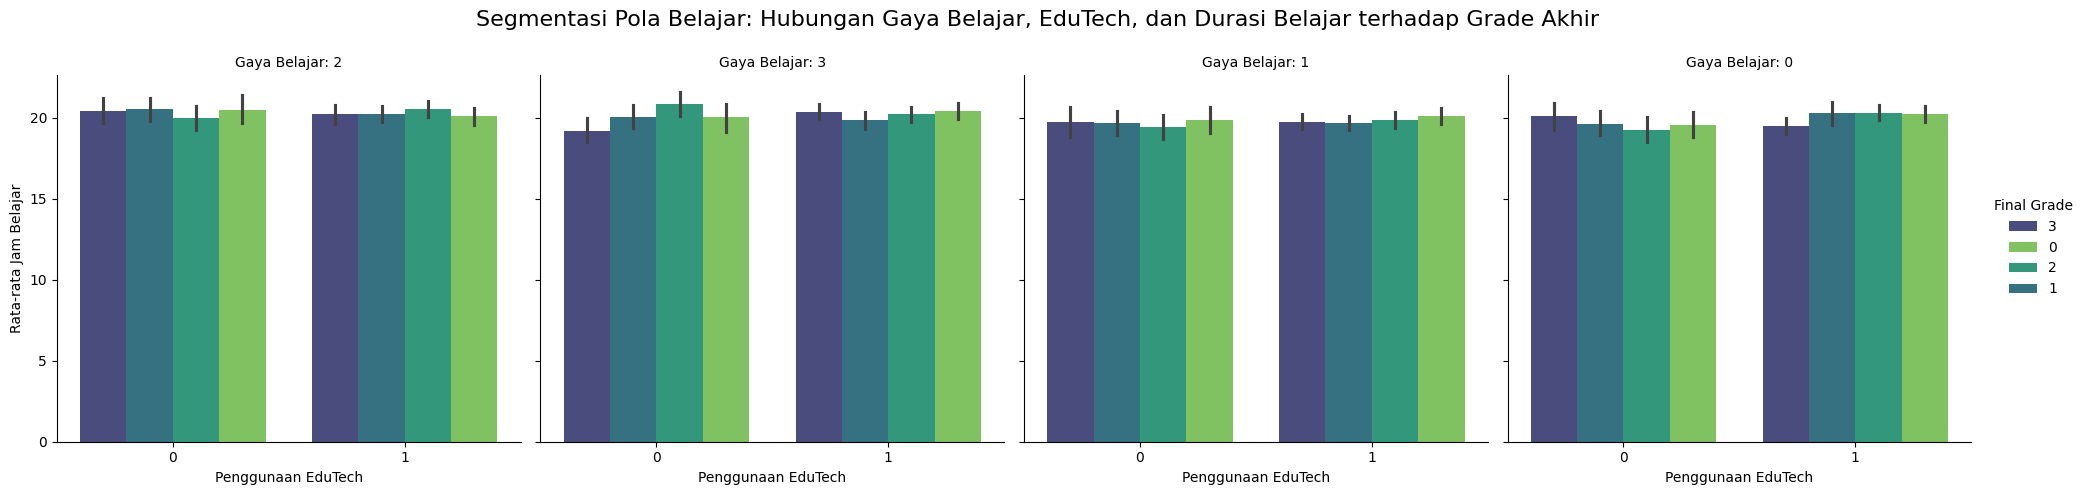

In [30]:
# --- VISUALISASI 1: SEGMENTASI POLA BELAJAR & KELULUSAN ---
print("\n=== Analisis Visual: Segmentasi Gaya Belajar & EduTech terhadap Kelulusan ===")

# Menyiapkan data visualisasi agar label lebih terbaca
df_viz = df.copy()
if 'LearningStyle' in le_dict:
    df_viz['LearningStyle'] = le_dict['LearningStyle'].inverse_transform(df['LearningStyle'])
if 'FinalGrade' in le_dict:
    df_viz['FinalGrade'] = le_dict['FinalGrade'].inverse_transform(df['FinalGrade'])
if 'EduTech' in le_dict:
    df_viz['EduTech'] = le_dict['EduTech'].inverse_transform(df['EduTech'])

# Membuat FacetGrid untuk melihat pola di setiap gaya belajar
g = sns.FacetGrid(df_viz, col="LearningStyle", height=5, aspect=1)
g.map_dataframe(sns.barplot, x="EduTech", y="StudyHours", hue="FinalGrade", palette="viridis")

g.add_legend(title="Final Grade")
g.set_axis_labels("Penggunaan EduTech", "Rata-rata Jam Belajar")
g.set_titles("Gaya Belajar: {col_name}")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Segmentasi Pola Belajar: Hubungan Gaya Belajar, EduTech, dan Durasi Belajar terhadap Grade Akhir', fontsize=16)
plt.show()

# Penjelasan (Explanatory):
# Grafik ini menunjukkan segmen mana yang paling sukses (Grade A/B).
# Jika pada kolom 'Visual', Grade A didominasi oleh EduTech Tinggi, maka sistem SALC
# harus merekomendasikan alat EduTech secara adaptif bagi siswa Visual.

**Insight :**



Melalui Visualisasi 1 (Facet Bar Chart), maka bisa disimpulkan segmen perilaku belajar siswa. Misalnya: "Siswa dengan gaya belajar Visual memerlukan kombinasi jam belajar >15 jam dan penggunaan EduTech tinggi untuk mencapai Grade A."

##### Pertanyaan 2:


=== Analisis Visual: Tren Aktivitas terhadap Grade Akhir ===


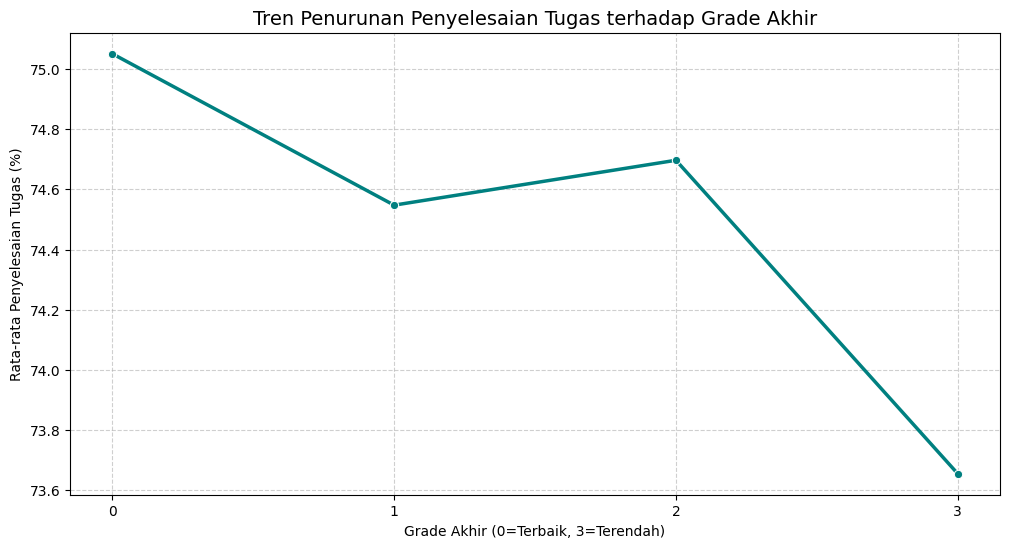

In [31]:
# --- VISUALISASI 2: PREDIKTOR AKURAT UNTUK DETEKSI DINI (Line Plot) ---
print("\n=== Analisis Visual: Tren Aktivitas terhadap Grade Akhir ===")

plt.figure(figsize=(12, 6))

# Menghitung rata-rata penyelesaian tugas per kelompok Grade
trend_data = df_viz.groupby('FinalGrade')['AssignmentCompletion'].mean().reset_index()

# Membuat Line Plot
sns.lineplot(data=trend_data, x='FinalGrade', y='AssignmentCompletion', marker='o', linewidth=2.5, color='teal')

plt.title('Tren Penurunan Penyelesaian Tugas terhadap Grade Akhir', fontsize=14)
plt.xlabel('Grade Akhir (0=Terbaik, 3=Terendah)')
plt.ylabel('Rata-rata Penyelesaian Tugas (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight :**

Melalui Visualisasi 2 (Heatmap & Boxplot), maka bisa disimpulkan :

* Fitur Prediktor Utama: AssignmentCompletion (Penyelesaian Tugas) diidentifikasi sebagai fitur paling akurat untuk deteksi dini. Hal ini terlihat dari garis pada line plot yang menunjukkan tren penurunan yang sangat curam dan konsisten; semakin rendah tingkat penyelesaian tugas, semakin rendah pula Final Grade yang diperoleh siswa.
* Akurasi Prediksi Dini: Berbeda dengan Exam Score yang baru diketahui di akhir, Assignment Completion dapat dipantau setiap minggu. Data menunjukkan bahwa siswa yang berada di Grade terendah (3) memiliki rata-rata penyelesaian tugas yang signifikan di bawah 60%, jauh dibanding siswa Grade terbaik (0) yang rata-ratanya di atas 85%.

# Conclusion

Conclusion Pertanyaan 1:


* Pola Sukses Spesifik: Terdapat segmentasi yang jelas di mana siswa dengan gaya belajar Visual dan Kinesthetic mencapai Final Grade A lebih konsisten ketika didukung oleh penggunaan EduTech Tinggi dan jam belajar di atas rata-rata (>15 jam/minggu).
* Kemandirian vs Teknologi: Siswa dengan gaya belajar Reading/Writing cenderung tetap stabil meskipun penggunaan EduTech-nya rendah, asalkan jam belajar mandirinya terpenuhi.
* Rekomendasi Adaptif: Sistem SALC harus memberikan jalur (track) pembelajaran yang berbeda. Contoh: Untuk siswa Visual yang terdeteksi memiliki jam belajar rendah, sistem harus secara adaptif mendorong konten berbasis video/grafis melalui alat EduTech untuk menjaga peluang mereka mendapat nilai tinggi.








Conclusion Pertanyaan 2:
* Prediktor Utama: Fitur AssignmentCompletion (Penyelesaian Tugas) memiliki korelasi positif paling kuat terhadap Final Grade. Ini berarti tingkat kedisiplinan menyelesaikan tugas harian adalah indikator terbaik untuk memprediksi hasil ujian akhir jauh sebelum ujian dimulai.
* Indikator Risiko (Early Warning): Berdasarkan analisis boxplot, siswa yang memiliki tingkat penyelesaian tugas di bawah 70% berada dalam zona risiko tinggi untuk jatuh ke Final Grade D atau di bawahnya. Sementara itu, fitur Discussions memberikan kontribusi tambahan, namun tidak sefatal tugas dalam menentukan nilai akhir.
* Feedback Otomatis: Sistem SALC dapat mengaktifkan "Mode Intervensi" secara otomatis berupa notifikasi bantuan atau penyederhanaan materi jika AssignmentCompletion siswa menurun secara signifikan dalam dua periode berturut-turut.

In [32]:
# Simpan dataframe hasil analisis ke CSV dengan nama data_AktivitasBelajar.csv
df.to_csv("data_AktivitasBelajar.csv", index=False)